# 05 — Regression
Predict player composite scores using Ridge Regression and Random Forest.
Two feature variants: baseline (rolling stats only) vs enhanced (+ team/opponent
strength context). Position-grouped models vs single global model.

| Metric | Description |
|--------|-------------|
| RMSE   | Root mean squared error |
| MAE    | Mean absolute error |
| R²     | Coefficient of determination |

**CV strategy:** `TimeSeriesSplit(n_splits=5)` within training seasons.


In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DS_DIR    = Path('../data/processed/datasets')
MODEL_DIR = Path('../data/models')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

of_train = pd.read_parquet(DS_DIR / 'outfield_train_scaled.parquet')
of_test  = pd.read_parquet(DS_DIR / 'outfield_test_scaled.parquet')

# Sort by date to respect temporal order
of_train = of_train.sort_values('match_date').reset_index(drop=True)
of_test  = of_test.sort_values('match_date').reset_index(drop=True)

print(f'Train: {of_train.shape}   Test: {of_test.shape}')
print(f'Target (composite_score) train nulls: {of_train["composite_score"].isnull().sum()}')


Train: (15288, 87)   Test: (4748, 87)
Target (composite_score) train nulls: 0


## 1 — Feature sets

In [2]:
# Identifiers and target — never features
NON_FEATURE = {
    'match_id', 'round', 'match_date', 'home_team', 'away_team',
    'player_id', 'player_name', 'team_id', 'team_name', 'shirt_number',
    'position_id', 'position_id_int', 'position_group', 'is_goalkeeper', 'season',
    'opponent', 'result', 'rating_title', 'composite_score',
}

# Baseline: rolling stats + home_away + minutes_played
BASELINE_FEAT = [c for c in of_train.columns
                 if c not in NON_FEATURE and c.startswith('roll5_')]
BASELINE_FEAT += ['home_away', 'minutes_played']

# Enhanced: baseline + team/opponent strength rolling averages
# (team_goals_scored and opp_goals_scored are per-match; we compute rolling averages below)
ENHANCED_EXTRA = ['roll5_team_goals_scored', 'roll5_opp_goals_scored']

def add_strength_features(df):
    df = df.copy().sort_values(['player_id', 'match_date'])
    # Rolling team/opp strength (per player history — proxy for fixture difficulty)
    for col in ['team_goals_scored', 'opp_goals_scored']:
        rolled = (
            df.groupby('player_id')[col]
            .apply(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )
        df[f'roll5_{col}'] = rolled
    df[[f'roll5_team_goals_scored', f'roll5_opp_goals_scored']] = (
        df[[f'roll5_team_goals_scored', f'roll5_opp_goals_scored']].fillna(
            df[['team_goals_scored', 'opp_goals_scored']].mean()
        )
    )
    return df

of_train = add_strength_features(of_train)
of_test  = add_strength_features(of_test)

ENHANCED_FEAT = BASELINE_FEAT + [c for c in ENHANCED_EXTRA if c in of_train.columns]

print(f'Baseline features : {len(BASELINE_FEAT)}')
print(f'Enhanced features : {len(ENHANCED_FEAT)}')


Baseline features : 34
Enhanced features : 36


## 2 — Baseline model
Predict training-set mean composite score per position group.


In [3]:
def evaluate(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{label:<35}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  (n={len(y_true):,})')
    return {'label': label, 'rmse': rmse, 'mae': mae, 'r2': r2, 'n': len(y_true)}

results = []

# Predict position-group mean
of_train_valid = of_train.dropna(subset=['composite_score'])
of_test_valid  = of_test.dropna(subset=['composite_score'])

pos_means = of_train_valid.groupby('position_group')['composite_score'].mean()
baseline_pred_train = of_train_valid['position_group'].map(pos_means)
baseline_pred_test  = of_test_valid['position_group'].map(pos_means).fillna(of_train_valid['composite_score'].mean())

results.append(evaluate(of_train_valid['composite_score'], baseline_pred_train, 'Baseline (pos mean) — train'))
results.append(evaluate(of_test_valid['composite_score'],  baseline_pred_test,  'Baseline (pos mean) — test'))


Baseline (pos mean) — train          RMSE=0.5574  MAE=0.4286  R²=0.0148  (n=15,288)
Baseline (pos mean) — test           RMSE=0.5671  MAE=0.4403  R²=0.0179  (n=4,748)


## 3 — Ridge Regression

In [4]:
tscv = TimeSeriesSplit(n_splits=5)

def run_ridge(X_tr, y_tr, X_te, y_te, label):
    param_grid = {'alpha': [0.01, 0.1, 1, 10, 100, 500]}
    ridge = GridSearchCV(Ridge(), param_grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    ridge.fit(X_tr, y_tr)
    best = ridge.best_estimator_
    print(f'  Best alpha: {best.alpha}')
    results.append(evaluate(y_tr, best.predict(X_tr), f'Ridge {label} — train'))
    results.append(evaluate(y_te, best.predict(X_te), f'Ridge {label} — test'))
    return best

of_tr = of_train_valid.dropna(subset=BASELINE_FEAT)
of_te = of_test_valid.dropna(subset=BASELINE_FEAT)

print('Ridge — baseline features:')
ridge_baseline = run_ridge(
    of_tr[BASELINE_FEAT], of_tr['composite_score'],
    of_te[BASELINE_FEAT], of_te['composite_score'],
    'baseline'
)

of_tr_e = of_train_valid.dropna(subset=ENHANCED_FEAT)
of_te_e = of_test_valid.dropna(subset=ENHANCED_FEAT)

print()
print('Ridge — enhanced features:')
ridge_enhanced = run_ridge(
    of_tr_e[ENHANCED_FEAT], of_tr_e['composite_score'],
    of_te_e[ENHANCED_FEAT], of_te_e['composite_score'],
    'enhanced'
)


Ridge — baseline features:


  Best alpha: 100
Ridge baseline — train               RMSE=0.3466  MAE=0.2661  R²=0.6192  (n=15,288)
Ridge baseline — test                RMSE=0.3464  MAE=0.2636  R²=0.6335  (n=4,748)

Ridge — enhanced features:


  Best alpha: 100
Ridge enhanced — train               RMSE=0.3318  MAE=0.2576  R²=0.6164  (n=14,538)
Ridge enhanced — test                RMSE=0.3176  MAE=0.2470  R²=0.6378  (n=4,292)


## 4 — Random Forest Regressor

In [5]:
from scipy.stats import randint, uniform

def run_rf(X_tr, y_tr, X_te, y_te, label, n_iter=30):
    param_dist = {
        'n_estimators' : [100, 200, 300],
        'max_depth'    : [4, 6, 8, 10, None],
        'min_samples_leaf': randint(5, 30),
        'max_features' : ['sqrt', 0.5],
    }
    rf = RandomizedSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        param_dist, n_iter=n_iter, cv=tscv,
        scoring='neg_root_mean_squared_error',
        random_state=42, n_jobs=-1
    )
    rf.fit(X_tr, y_tr)
    best = rf.best_estimator_
    print(f'  Best params: {rf.best_params_}')
    results.append(evaluate(y_tr, best.predict(X_tr), f'RF {label} — train'))
    results.append(evaluate(y_te, best.predict(X_te), f'RF {label} — test'))
    return best

print('Random Forest — baseline features:')
rf_baseline = run_rf(
    of_tr[BASELINE_FEAT], of_tr['composite_score'],
    of_te[BASELINE_FEAT], of_te['composite_score'],
    'baseline'
)

print()
print('Random Forest — enhanced features:')
rf_enhanced = run_rf(
    of_tr_e[ENHANCED_FEAT], of_tr_e['composite_score'],
    of_te_e[ENHANCED_FEAT], of_te_e['composite_score'],
    'enhanced'
)


Random Forest — baseline features:


  Best params: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 12, 'n_estimators': 300}
RF baseline — train                  RMSE=0.1722  MAE=0.1081  R²=0.9060  (n=15,288)


RF baseline — test                   RMSE=0.2365  MAE=0.1538  R²=0.8292  (n=4,748)

Random Forest — enhanced features:


  Best params: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 12, 'n_estimators': 300}


RF enhanced — train                  RMSE=0.1560  MAE=0.1019  R²=0.9152  (n=14,538)
RF enhanced — test                   RMSE=0.2027  MAE=0.1396  R²=0.8525  (n=4,292)


## 5 — Position-grouped RF (best model)

In [6]:
grouped_models = {}
grouped_results = []

for pos in ['defender', 'midfielder', 'winger', 'forward']:
    print(f'\n--- {pos} ---')
    tr_pos = of_tr_e[of_tr_e['position_group'] == pos]
    te_pos = of_te_e[of_te_e['position_group'] == pos]
    if len(tr_pos) < 50:
        print(f'  Skipped — only {len(tr_pos)} train rows')
        continue

    param_dist = {
        'n_estimators'    : [100, 200, 300],
        'max_depth'       : [4, 6, 8, 10, None],
        'min_samples_leaf': randint(3, 20),
        'max_features'    : ['sqrt', 0.5],
    }
    rf_pos = RandomizedSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        param_dist, n_iter=20, cv=tscv,
        scoring='neg_root_mean_squared_error',
        random_state=42, n_jobs=-1
    )
    rf_pos.fit(tr_pos[ENHANCED_FEAT], tr_pos['composite_score'])
    best = rf_pos.best_estimator_
    print(f'  Best params: {rf_pos.best_params_}')

    r = evaluate(te_pos['composite_score'], best.predict(te_pos[ENHANCED_FEAT]),
                 f'RF grouped {pos} — test')
    grouped_results.append(r)
    grouped_models[pos] = best

# Save position-grouped RF models
for pos, model in grouped_models.items():
    path = MODEL_DIR / f'rf_regression_{pos}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f'✓ rf_regression_{pos}.pkl saved')

print()
print('RF grouped enhanced — overall test R²:',
      round(np.mean([r['r2'] for r in grouped_results]), 4))



--- defender ---


  Best params: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 8, 'n_estimators': 200}
RF grouped defender — test           RMSE=0.0923  MAE=0.0646  R²=0.9657  (n=1,747)

--- midfielder ---


  Best params: {'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 100}
RF grouped midfielder — test         RMSE=0.1163  MAE=0.0860  R²=0.9410  (n=977)

--- winger ---


  Best params: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 8, 'n_estimators': 200}
RF grouped winger — test             RMSE=0.1372  MAE=0.0926  R²=0.9423  (n=1,061)

--- forward ---


  Best params: {'max_depth': 6, 'max_features': 0.5, 'min_samples_leaf': 3, 'n_estimators': 200}
RF grouped forward — test            RMSE=0.1409  MAE=0.1084  R²=0.9381  (n=507)
✓ rf_regression_defender.pkl saved
✓ rf_regression_midfielder.pkl saved
✓ rf_regression_winger.pkl saved
✓ rf_regression_forward.pkl saved

RF grouped enhanced — overall test R²: 0.9468


## 6 — Results summary table

In [7]:
results_df = pd.DataFrame(results)
print(results_df[results_df['label'].str.contains('test')].sort_values('r2', ascending=False).to_string(index=False))


                     label     rmse      mae       r2    n
        RF enhanced — test 0.202701 0.139626 0.852453 4292
        RF baseline — test 0.236467 0.153763 0.829243 4748
     Ridge enhanced — test 0.317578 0.246969 0.637824 4292
     Ridge baseline — test 0.346450 0.263637 0.633464 4748
Baseline (pos mean) — test 0.567107 0.440304 0.017878 4748

## 7 — Feature importance (best RF model — enhanced global)

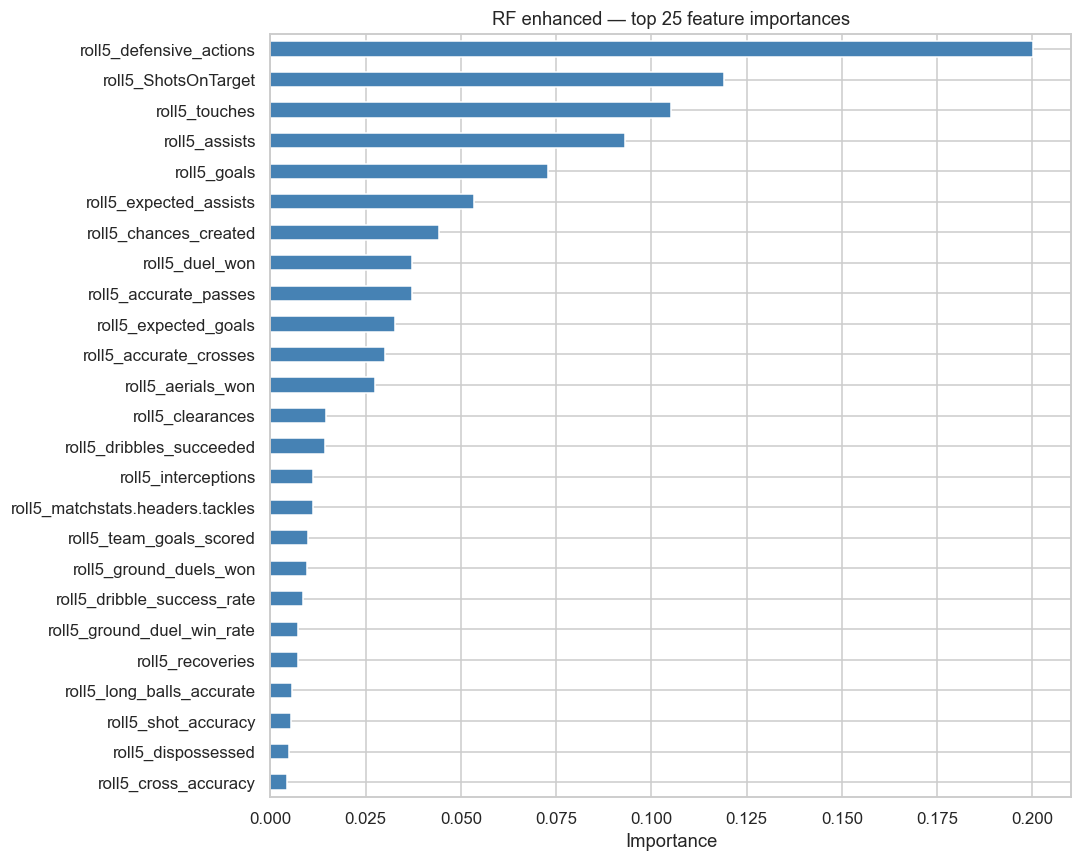

Top 10 features:
roll5_defensive_actions    0.2003
roll5_ShotsOnTarget        0.1190
roll5_touches              0.1051
roll5_assists              0.0932
roll5_goals                0.0730
roll5_expected_assists     0.0536
roll5_chances_created      0.0443
roll5_duel_won             0.0372
roll5_accurate_passes      0.0371
roll5_expected_goals       0.0327


In [8]:
importances = pd.Series(rf_enhanced.feature_importances_, index=ENHANCED_FEAT).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importances.head(25).plot.barh(ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('RF enhanced — top 25 feature importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importances.head(10).round(4).to_string())


## 8 — Per-position test R² bar chart

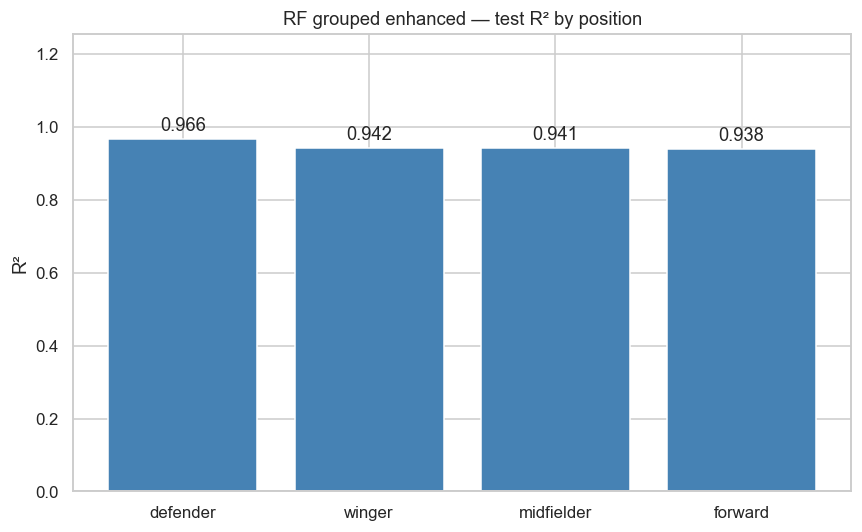

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
gr_df = pd.DataFrame(grouped_results)
gr_df = gr_df.sort_values('r2', ascending=False)
bars = ax.bar(gr_df['label'].str.replace('RF grouped ', '').str.replace(' — test', ''),
              gr_df['r2'], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_ylabel('R²')
ax.set_title('RF grouped enhanced — test R² by position')
ax.set_ylim(0, max(gr_df['r2'].max() * 1.3, 0.2))
plt.tight_layout()
plt.show()
